Dataset shape: (39438, 17)

First few rows:
        date          region       river      basin  elevation  temperature  \
0 2018-01-01    Bishkek_City   Ala-Archa        Chu        800         -6.2   
1 2018-01-01     Tokmok_Area         Chu        Chu        820         -9.1   
2 2018-01-01  Kemin_District  Chon-Kemin        Chu       1300         -4.5   
3 2018-01-01  Sokuluk_Valley     Sokuluk        Chu       1100         -8.6   
4 2018-01-01    Karakol_City     Karakol  Issyk-Kul       1750        -16.7   

   precipitation  snowmelt  river_level  flood_threshold  flood_status  \
0            0.0       0.0         0.93              2.5             0   
1            0.0       0.0         0.93              2.8             0   
2            0.0       0.0         0.93              1.8             0   
3            0.0       0.0         0.93              1.7             0   
4            0.0       0.0         0.63              1.9             0   

   soil_moisture  upstream_dam_level

C:\Users\Aelina.Daniiarkyzy\AppData\Local\Temp\ipykernel_17236\1074120351.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  elevation_stats = df.groupby('elevation_range').agg({
C:\Users\Aelina.Daniiarkyzy\AppData\Local\Temp\ipykernel_17236\1074120351.py:248: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  elevation_flood = df.groupby('elevation_range')['flood_status'].mean() * 100



EDA complete! Visualizations saved in 'plots' directory.


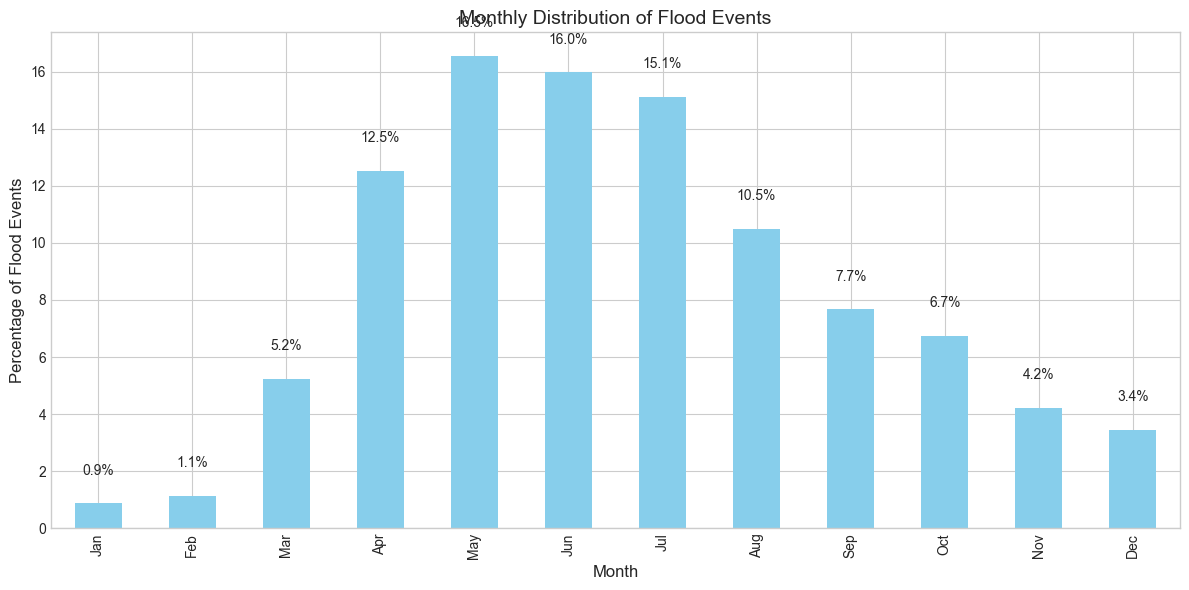

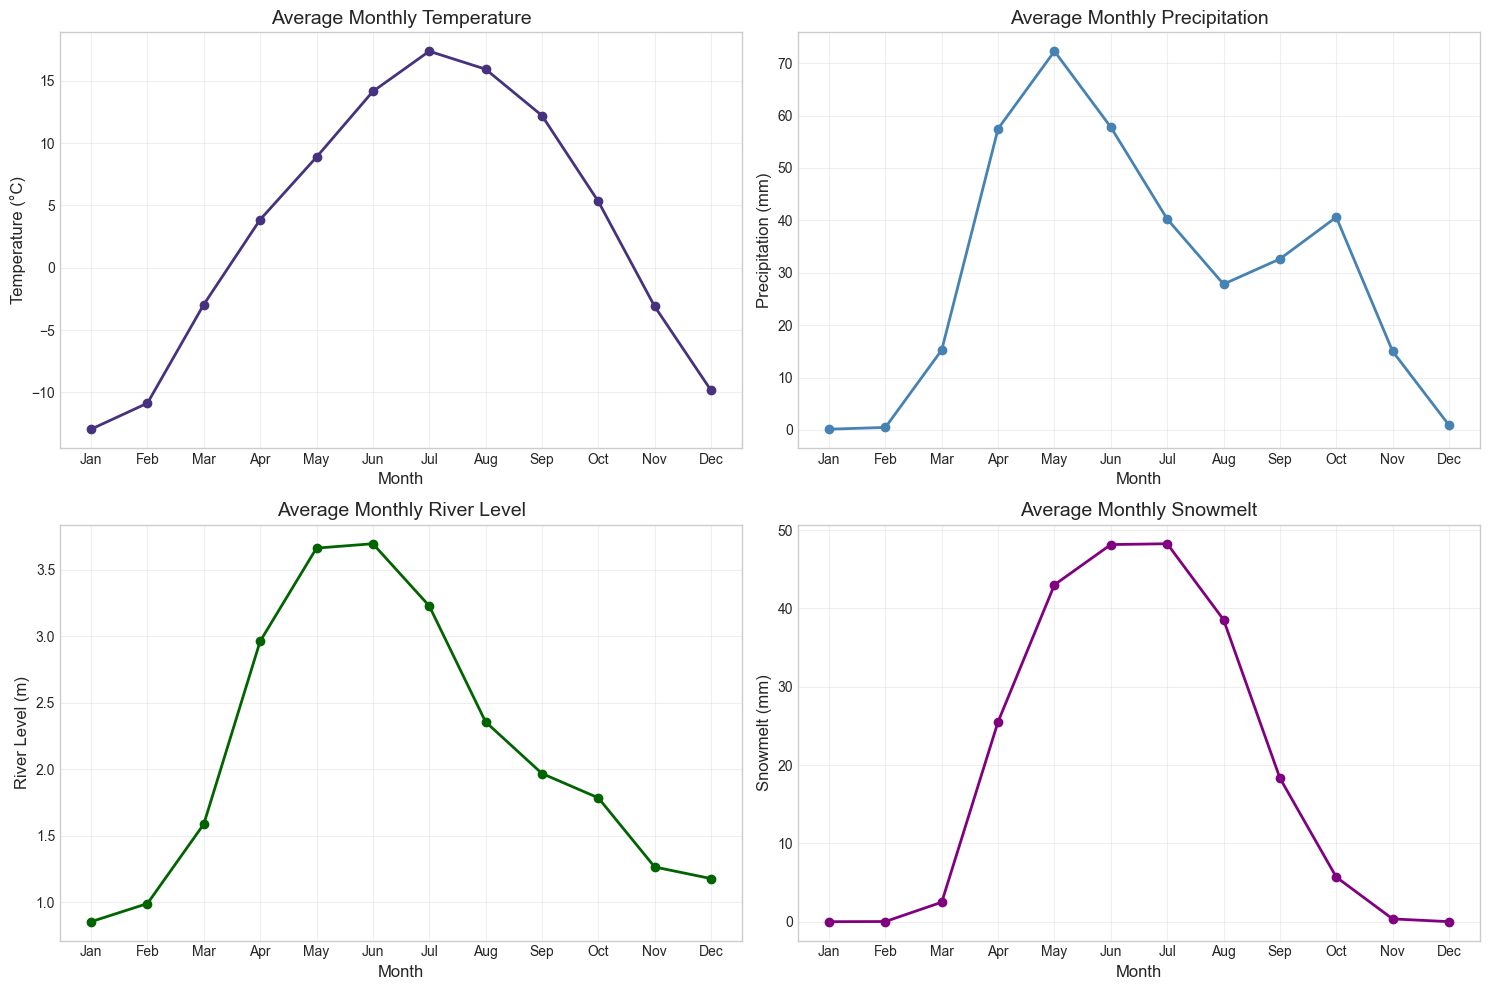

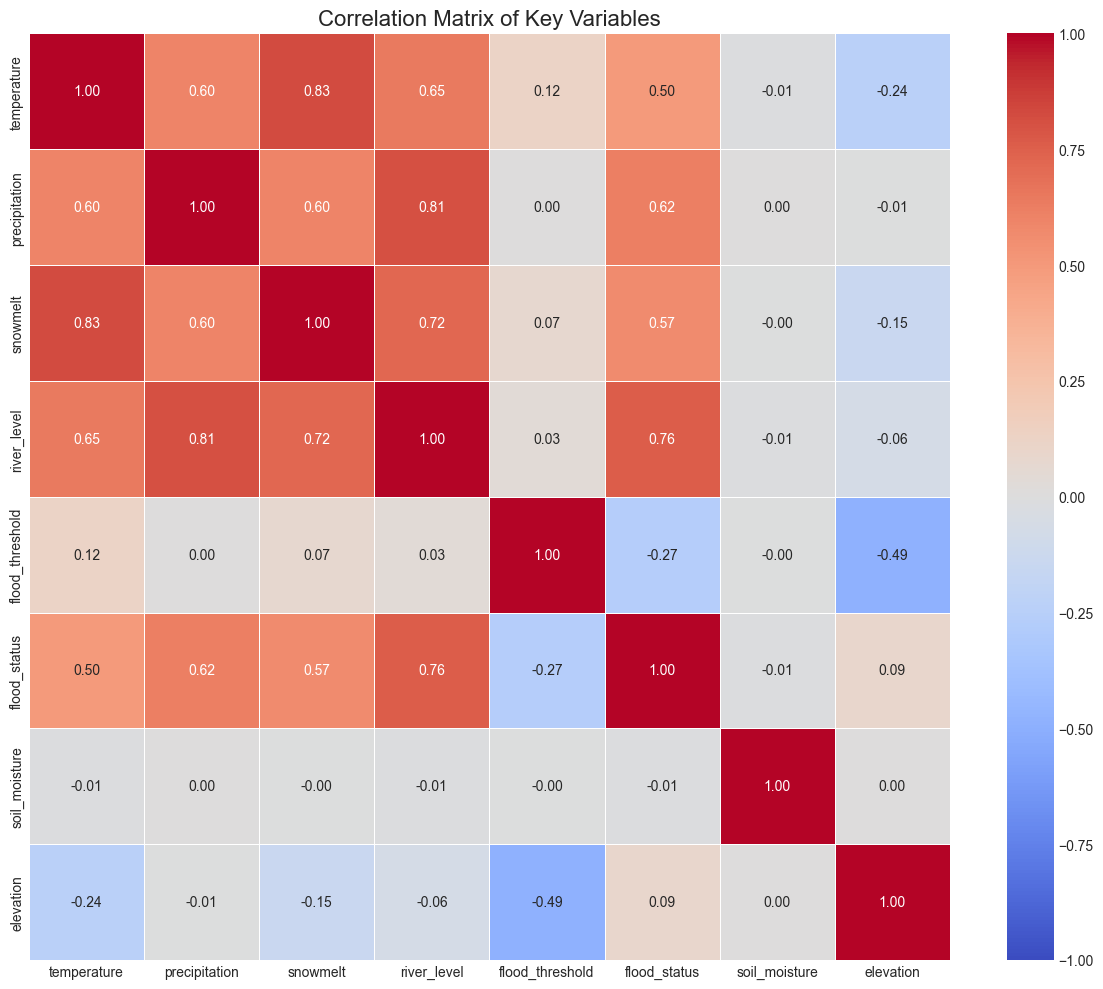

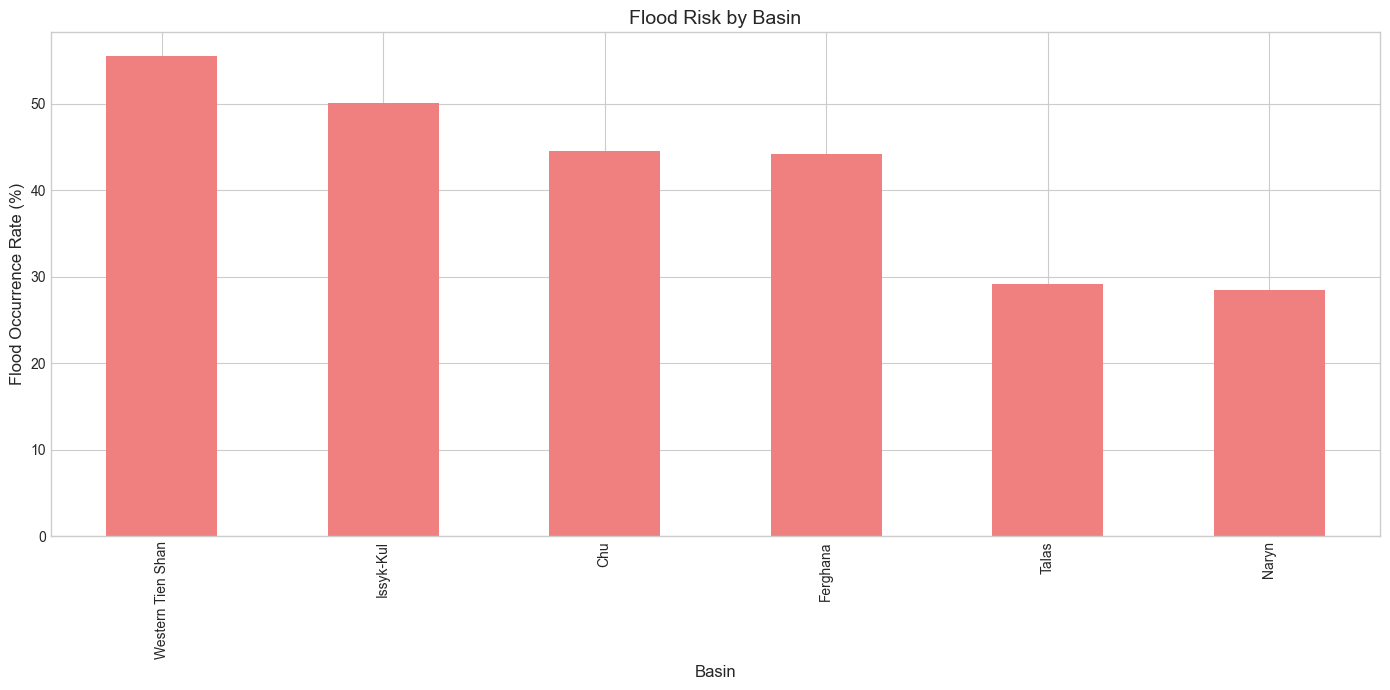

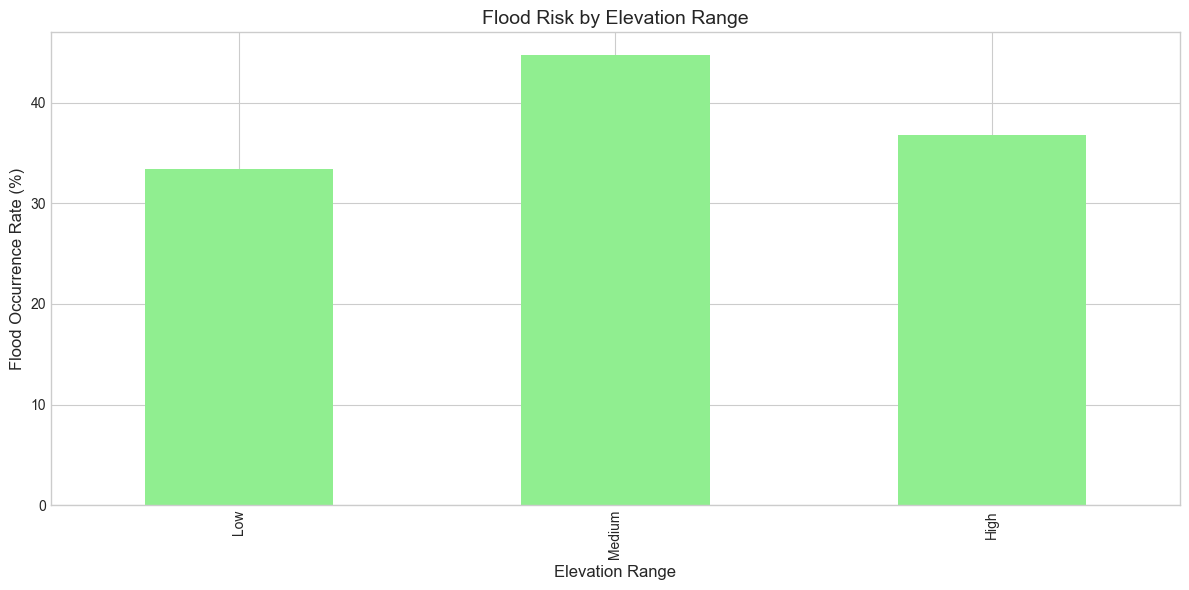

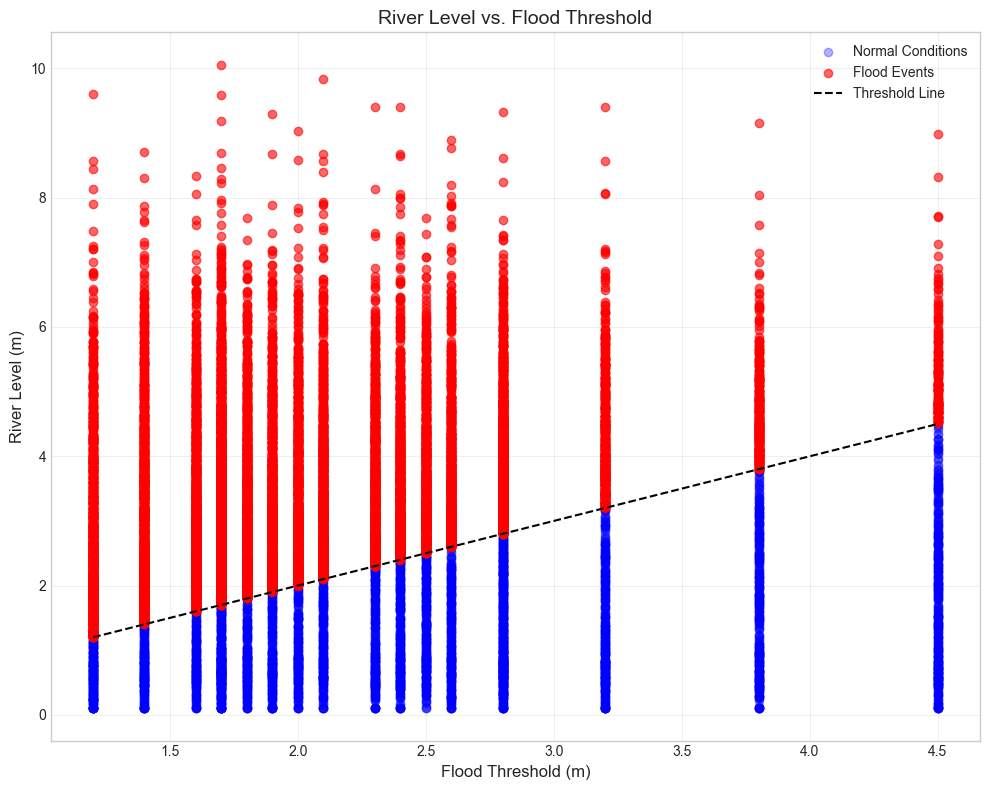

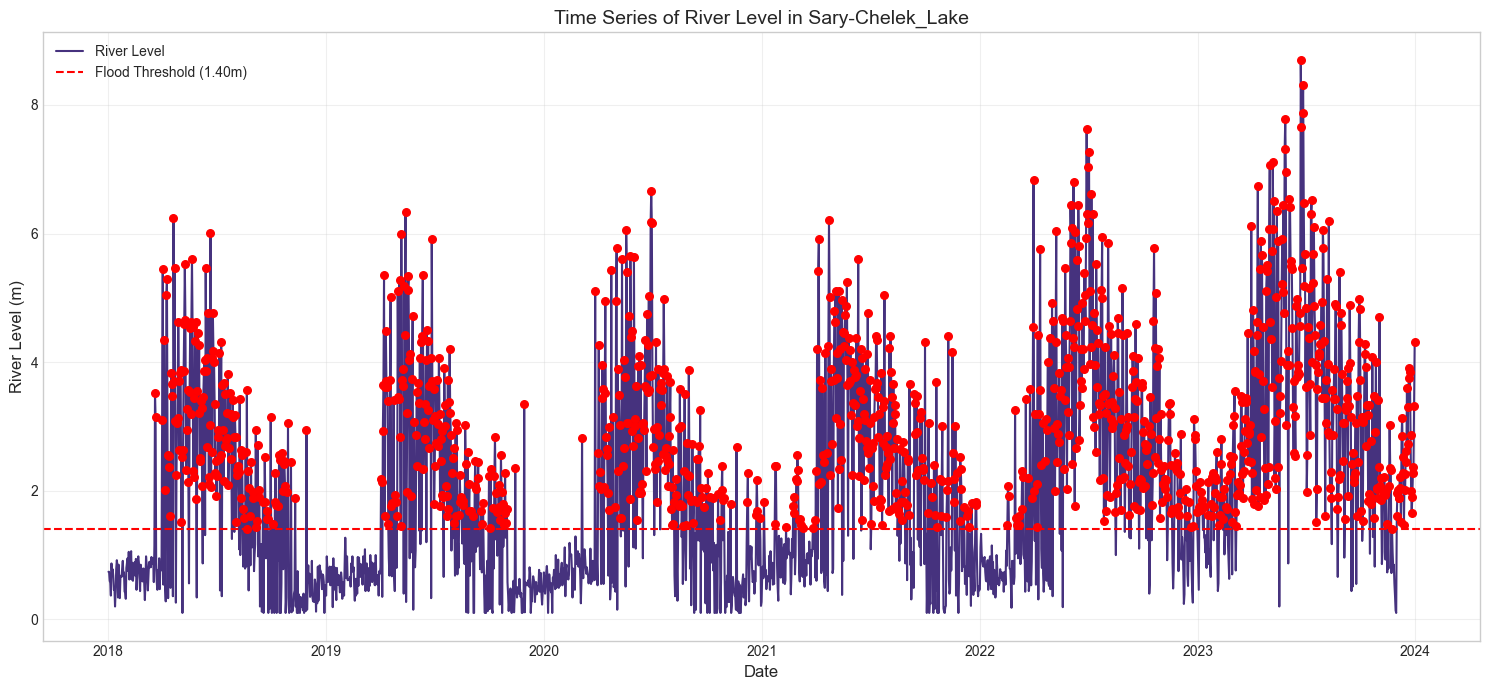

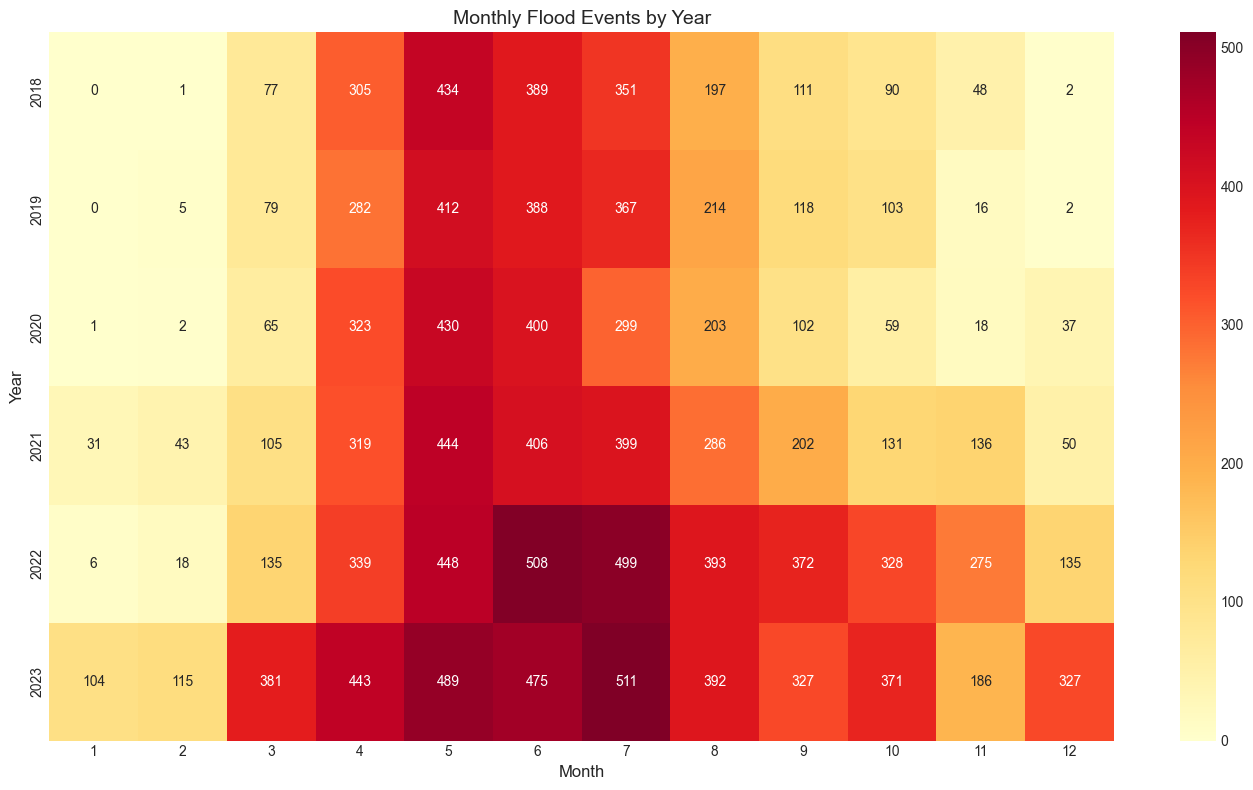

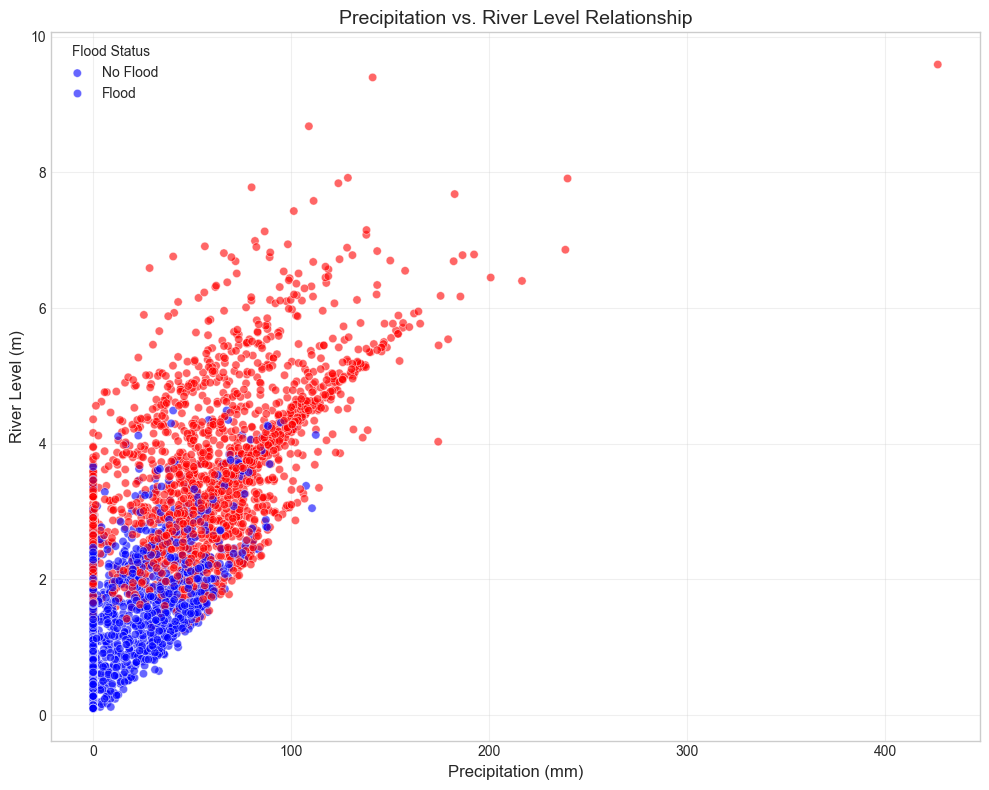

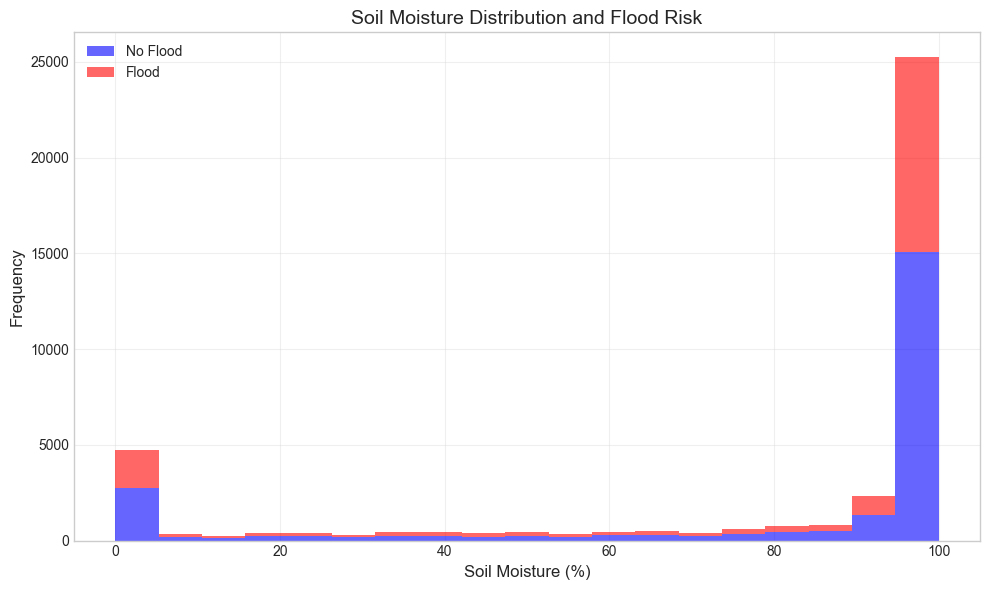

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Load the dataset
df = pd.read_csv('kyrgyzstan_flood_data.csv')

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Add temporal columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
# Create seasons - fixing the duplicate 'Winter' label issue
season_map = {
    1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall',
    12: 'Winter'
}
df['season'] = df['month'].map(season_map)

# Basic dataset information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check data types and missing values
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

# Check unique values in categorical columns
print("\nUnique values in categorical columns:")
print("Regions:", df['region'].nunique())
print("Rivers:", df['river'].nunique())
print("Basins:", df['basin'].nunique())

# Count flood events
flood_count = df['flood_status'].sum()
flood_percent = (flood_count / len(df)) * 100
print(f"\nFlood events: {flood_count} ({flood_percent:.2f}% of all data points)")

# Distribution of flood events by region
region_floods = df.groupby('region')['flood_status'].sum().sort_values(ascending=False)
print("\nFlood events by region (top 10):")
print(region_floods.head(10))

# Distribution of flood events by basin
basin_floods = df.groupby('basin')['flood_status'].sum().sort_values(ascending=False)
print("\nFlood events by basin:")
print(basin_floods)

# Distribution of flood events by month
monthly_floods = df.groupby('month')['flood_status'].sum()
print("\nFlood events by month:")
print(monthly_floods)

# Distribution of flood events by season
seasonal_floods = df.groupby('season')['flood_status'].sum()
print("\nFlood events by season:")
print(seasonal_floods)

# Correlation between numerical variables
corr_columns = ['temperature', 'precipitation', 'snowmelt', 'river_level', 
                'flood_threshold', 'flood_status', 'soil_moisture', 'elevation']
corr_matrix = df[corr_columns].corr()
print("\nCorrelation matrix:")
print(corr_matrix.round(2))

# Statistical characteristics by region
region_stats = df.groupby('region').agg({
    'temperature': 'mean',
    'precipitation': 'mean',
    'snowmelt': 'mean',
    'river_level': 'mean',
    'soil_moisture': 'mean',
    'flood_status': ['sum', 'mean']
}).sort_values(('flood_status', 'sum'), ascending=False)
print("\nStatistical characteristics by region (top 10):")
print(region_stats.head(10).round(2))

# Statistical characteristics by basin
basin_stats = df.groupby('basin').agg({
    'temperature': 'mean',
    'precipitation': 'mean',
    'snowmelt': 'mean',
    'river_level': 'mean',
    'soil_moisture': 'mean',
    'flood_status': ['sum', 'mean']
})
print("\nStatistical characteristics by basin:")
print(basin_stats.round(2))

# Create elevation ranges
df['elevation_range'] = pd.cut(df['elevation'], bins=[0, 1000, 2000, 4000], labels=['Low', 'Medium', 'High'])
elevation_stats = df.groupby('elevation_range').agg({
    'temperature': 'mean',
    'precipitation': 'mean',
    'snowmelt': 'mean',
    'river_level': 'mean',
    'soil_moisture': 'mean', 
    'flood_status': ['sum', 'mean']
})
print("\nStatistical characteristics by elevation range:")
print(elevation_stats.round(2))

# Seasonal variation analysis
seasonal_stats = df.groupby(['basin', 'season']).agg({
    'temperature': 'mean', 
    'precipitation': 'mean',
    'snowmelt': 'mean',
    'river_level': 'mean',
    'flood_status': 'mean'
})
print("\nSeasonal variation by basin (showing Chu basin):")
print(seasonal_stats.loc['Chu'].round(2))

# Examine upstream dam impact
dam_influence = df[df['upstream_dam_level'].notna()].groupby('region').agg({
    'river_level': 'mean',
    'upstream_dam_level': 'mean',
    'flood_status': ['sum', 'mean']
})
print("\nUpstream dam influence:")
print(dam_influence.round(2))

# Check for outliers
print("\nStatistics for potential outliers:")
print("Temperature range:", df['temperature'].min(), "to", df['temperature'].max())
print("Precipitation range:", df['precipitation'].min(), "to", df['precipitation'].max())
print("River level range:", df['river_level'].min(), "to", df['river_level'].max())

# Analyze temporal patterns
years = df['year'].unique()
yearly_floods = df.groupby('year')['flood_status'].sum()
print("\nYearly flood patterns:")
print(yearly_floods)

# Analyze relationship between river level and flood threshold
df['level_to_threshold_ratio'] = df['river_level'] / df['flood_threshold']
print("\nLevel-to-threshold ratio statistics:")
print(df['level_to_threshold_ratio'].describe().round(3))

# Percentage of days when river level exceeds 90% of threshold (near-miss events)
near_miss = df[(df['level_to_threshold_ratio'] > 0.9) & (df['level_to_threshold_ratio'] < 1)]
near_miss_percent = (len(near_miss) / len(df)) * 100
print(f"Near-miss events (90-100% of threshold): {len(near_miss)} ({near_miss_percent:.2f}% of all data points)")

# VISUALIZATIONS

# Create a directory for saving plots
import os
if not os.path.exists('plots'):
    os.makedirs('plots')

# 1. Monthly distribution of flood events
plt.figure(figsize=(12, 6))
monthly_floods_percent = monthly_floods / monthly_floods.sum() * 100
ax = monthly_floods_percent.plot(kind='bar', color='skyblue')
plt.title('Monthly Distribution of Flood Events', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage of Flood Events', fontsize=12)
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Add percentage labels on top of bars
for i, v in enumerate(monthly_floods_percent):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.savefig('plots/monthly_flood_distribution.png', dpi=300)

# 2. Seasonal patterns of key variables for flood prediction
plt.figure(figsize=(15, 10))

# Temperature
plt.subplot(2, 2, 1)
df.groupby('month')['temperature'].mean().plot(kind='line', marker='o', linewidth=2)
plt.title('Average Monthly Temperature', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)

# Precipitation
plt.subplot(2, 2, 2)
df.groupby('month')['precipitation'].mean().plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Average Monthly Precipitation', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)

# River Level
plt.subplot(2, 2, 3)
df.groupby('month')['river_level'].mean().plot(kind='line', marker='o', color='darkgreen', linewidth=2)
plt.title('Average Monthly River Level', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('River Level (m)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)

# Snowmelt
plt.subplot(2, 2, 4)
df.groupby('month')['snowmelt'].mean().plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Average Monthly Snowmelt', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Snowmelt (mm)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/seasonal_patterns.png', dpi=300)

# 3. Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Key Variables', fontsize=16)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=300)

# 4. Basin comparison for flood risk
plt.figure(figsize=(14, 7))
basin_flood_rate = df.groupby('basin')['flood_status'].mean() * 100
basin_flood_rate.sort_values(ascending=False).plot(kind='bar', color='lightcoral')
plt.title('Flood Risk by Basin', fontsize=14)
plt.xlabel('Basin', fontsize=12)
plt.ylabel('Flood Occurrence Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/basin_flood_risk.png', dpi=300)

# 5. Explore relationship between elevation and flood risk
plt.figure(figsize=(12, 6))
elevation_flood = df.groupby('elevation_range')['flood_status'].mean() * 100
elevation_flood.plot(kind='bar', color='lightgreen')
plt.title('Flood Risk by Elevation Range', fontsize=14)
plt.xlabel('Elevation Range', fontsize=12)
plt.ylabel('Flood Occurrence Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/elevation_flood_risk.png', dpi=300)

# 6. River level vs. flood threshold analysis (scatterplot with flood events highlighted)
plt.figure(figsize=(10, 8))
# Create sample from non-flood events (for clarity)
non_flood_sample = df[df['flood_status'] == 0].sample(min(5000, df[df['flood_status'] == 0].shape[0]))
# Plot non-flood events
plt.scatter(non_flood_sample['flood_threshold'], non_flood_sample['river_level'], 
            alpha=0.3, color='blue', label='Normal Conditions')
# Plot flood events
plt.scatter(df[df['flood_status'] == 1]['flood_threshold'], df[df['flood_status'] == 1]['river_level'], 
            alpha=0.6, color='red', label='Flood Events')
# Plot threshold line
thresholds = np.linspace(df['flood_threshold'].min(), df['flood_threshold'].max(), 100)
plt.plot(thresholds, thresholds, 'k--', label='Threshold Line')
plt.title('River Level vs. Flood Threshold', fontsize=14)
plt.xlabel('Flood Threshold (m)', fontsize=12)
plt.ylabel('River Level (m)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/river_level_vs_threshold.png', dpi=300)

# 7. Time series of flood events for a specific region
# Select a region with significant flood events
top_flood_region = region_floods.index[0]
region_data = df[df['region'] == top_flood_region].sort_values('date')

plt.figure(figsize=(15, 7))
plt.plot(region_data['date'], region_data['river_level'], label='River Level')
plt.axhline(y=region_data['flood_threshold'].iloc[0], color='r', linestyle='--', 
            label=f'Flood Threshold ({region_data["flood_threshold"].iloc[0]:.2f}m)')
# Highlight flood events
flood_dates = region_data[region_data['flood_status'] == 1]['date']
flood_levels = region_data[region_data['flood_status'] == 1]['river_level']
plt.scatter(flood_dates, flood_levels, color='red', s=30, zorder=5)

plt.title(f'Time Series of River Level in {top_flood_region}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('River Level (m)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'plots/time_series_{top_flood_region}.png', dpi=300)

# 8. Compare flood patterns across years
yearly_monthly_floods = df.groupby(['year', 'month'])['flood_status'].sum().unstack()
plt.figure(figsize=(14, 8))
sns.heatmap(yearly_monthly_floods, cmap='YlOrRd', annot=True, fmt='g')
plt.title('Monthly Flood Events by Year', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig('plots/yearly_monthly_floods.png', dpi=300)

# 9. Precipitation vs. river level relationship
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df.sample(5000), x='precipitation', y='river_level', hue='flood_status', 
                palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title('Precipitation vs. River Level Relationship', fontsize=14)
plt.xlabel('Precipitation (mm)', fontsize=12)
plt.ylabel('River Level (m)', fontsize=12)
plt.legend(title='Flood Status', labels=['No Flood', 'Flood'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/precipitation_vs_river_level.png', dpi=300)

# 10. Soil moisture and flood risk
plt.figure(figsize=(10, 6))
bins = np.linspace(df['soil_moisture'].min(), df['soil_moisture'].max(), 20)
flood_soil = df[df['flood_status'] == 1]['soil_moisture']
non_flood_soil = df[df['flood_status'] == 0]['soil_moisture']

plt.hist([non_flood_soil, flood_soil], bins=bins, stacked=True, 
         color=['blue', 'red'], alpha=0.6, label=['No Flood', 'Flood'])
plt.title('Soil Moisture Distribution and Flood Risk', fontsize=14)
plt.xlabel('Soil Moisture (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/soil_moisture_flood_risk.png', dpi=300)

print("\nEDA complete! Visualizations saved in 'plots' directory.")